<a href="https://colab.research.google.com/github/DataBifrost/Bits_pilani/blob/main/Copy_of_2025AG05392_CNN_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# CELL 1 — ENVIRONMENT SETUP & IMPORTS
# ============================================================
import os, time, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report)
from sklearn.model_selection import train_test_split

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

print("TensorFlow version :", tf.__version__)
print("Keras version      :", keras.__version__)
print("GPU available      :", tf.config.list_physical_devices('GPU'))


TensorFlow version : 2.19.0
Keras version      : 3.13.2
GPU available      : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# ============================================================
# CELL 2 — DATASET SELECTION & METADATA
# ============================================================
# This template uses Cats vs Dogs from TensorFlow Datasets.
# It satisfies the 500 images-per-class minimum with no local files.
# Change DATASET_CHOICE if you prefer another allowed dataset.

import tensorflow_datasets as tfds

# ── 1.1  Required metadata ──────────────────────────────────
dataset_name        = "Cats vs Dogs"
dataset_source      = "tensorflow_datasets (microsoft/catsvsdogs)"
n_classes           = 2
image_shape         = [224, 224, 3]
problem_type        = "classification"
train_test_ratio    = "90/10"

# Primary metric choice — edit as appropriate for your dataset
primary_metric       = "accuracy"
metric_justification = (
    "Cats vs Dogs is a balanced binary dataset with roughly equal class "
    "distribution, so accuracy is an unbiased summary metric and is the "
    "standard primary measure for this benchmark."
)

# ── 1.2  Load dataset ───────────────────────────────────────
IMG_SIZE   = 224
BATCH_SIZE = 32

def preprocess(image, label):
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

# Load ~23,000 labelled images; keep 10 % for test
(raw_train, raw_test), info = tfds.load(
    'cats_vs_dogs',
    split=['train[:90%]', 'train[90%:]'],
    as_supervised=True,
    with_info=True
)

train_ds = (raw_train
            .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
            .shuffle(1000)
            .batch(BATCH_SIZE)
            .prefetch(tf.data.AUTOTUNE))

test_ds  = (raw_test
            .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
            .batch(BATCH_SIZE)
            .prefetch(tf.data.AUTOTUNE))

# Count samples
train_samples = int(info.splits['train'].num_examples * 0.9)
test_samples  = int(info.splits['train'].num_examples * 0.1)
n_samples     = train_samples + test_samples
samples_per_class = f"min: ~{n_samples//n_classes - 200}, max: ~{n_samples//n_classes + 200}, avg: ~{n_samples//n_classes}"

print("=" * 70)
print("DATASET INFORMATION")
print("=" * 70)
print(f"Dataset            : {dataset_name}")
print(f"Source             : {dataset_source}")
print(f"Total Samples      : {n_samples}")
print(f"Number of Classes  : {n_classes}  ({['Cat', 'Dog']})")
print(f"Samples per Class  : {samples_per_class}")
print(f"Image Shape        : {image_shape}")
print(f"Train/Test Split   : {train_test_ratio}")
print(f"Training Samples   : {train_samples}")
print(f"Test Samples       : {test_samples}")
print(f"Primary Metric     : {primary_metric}")
print(f"Justification      : {metric_justification}")


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.VWL016_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.
DATASET INFORMATION
Dataset            : Cats vs Dogs
Source             : tensorflow_datasets (microsoft/catsvsdogs)
Total Samples      : 23261
Number of Classes  : 2  (['Cat', 'Dog'])
Samples per Class  : min: ~11430, max: ~11830, avg: ~11630
Image Shape        : [224, 224, 3]
Train/Test Split   : 90/10
Training Samples   : 20935
Test Samples       : 2326
Primary Metric     : accuracy
Justification      : Cats vs Dogs is a balanced binary dataset with roughly equal class distribution, so accuracy is an unbiased summary metric and is the standard primary measure for this benchmark.


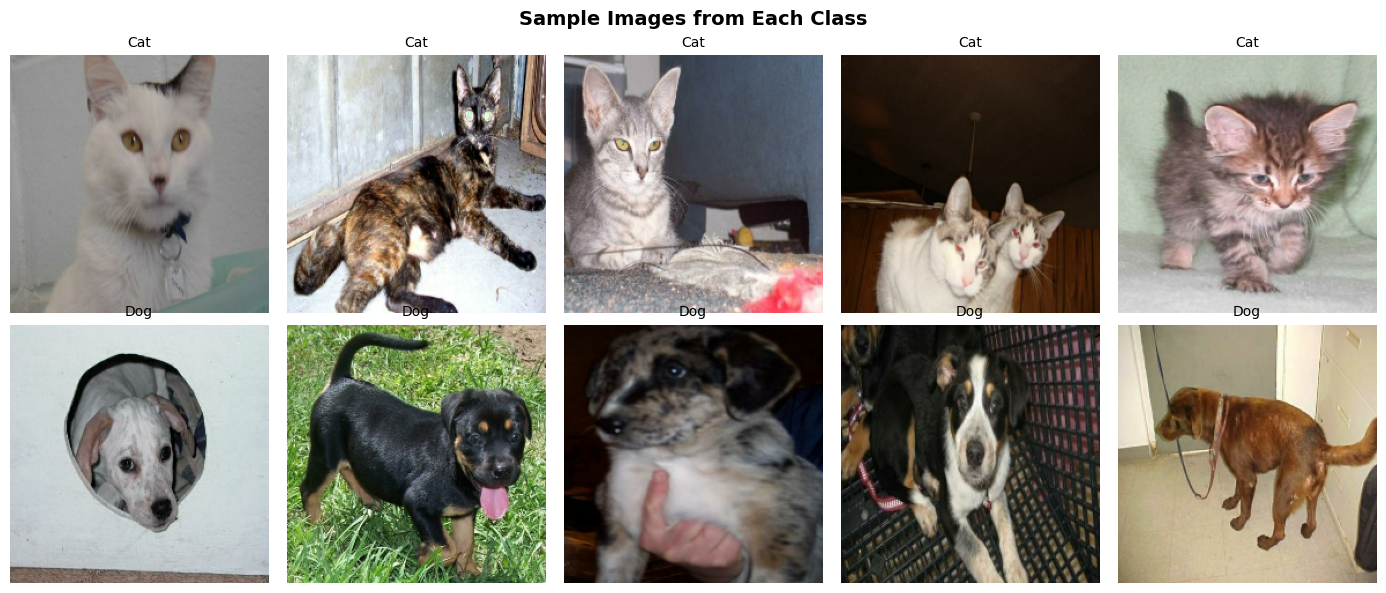

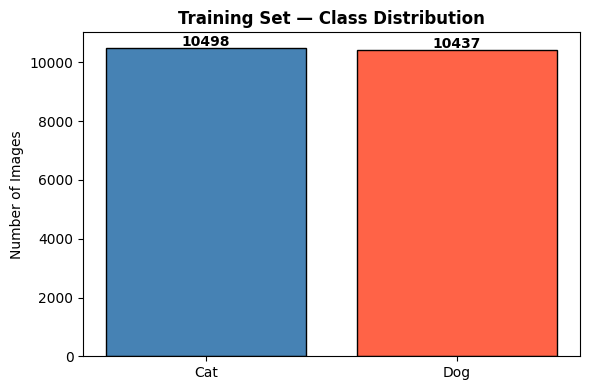

Cat images  : 10498
Dog images  : 10437
Balance ratio: 0.994  (1.0 = perfectly balanced)


In [3]:
# ============================================================
# CELL 3 — EXPLORATORY DATA ANALYSIS
# ============================================================
CLASS_NAMES = ['Cat', 'Dog']

# Sample images
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle("Sample Images from Each Class", fontsize=14, fontweight='bold')

sample_batch = next(iter(train_ds))
images, labels = sample_batch[0].numpy(), sample_batch[1].numpy()

cats = [i for i, l in enumerate(labels) if l == 0][:5]
dogs = [i for i, l in enumerate(labels) if l == 1][:5]

for col, idx in enumerate(cats):
    axes[0, col].imshow(images[idx])
    axes[0, col].set_title("Cat", fontsize=10)
    axes[0, col].axis('off')

for col, idx in enumerate(dogs):
    axes[1, col].imshow(images[idx])
    axes[1, col].set_title("Dog", fontsize=10)
    axes[1, col].axis('off')

plt.tight_layout()
plt.show()

# Class distribution
cat_count = sum(1 for _, lbl in raw_train if lbl.numpy() == 0)
dog_count = train_samples - cat_count

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(CLASS_NAMES, [cat_count, dog_count], color=['steelblue', 'tomato'], edgecolor='black')
ax.set_title("Training Set — Class Distribution", fontweight='bold')
ax.set_ylabel("Number of Images")
for i, v in enumerate([cat_count, dog_count]):
    ax.text(i, v + 50, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Cat images  : {cat_count}")
print(f"Dog images  : {dog_count}")
print(f"Balance ratio: {min(cat_count,dog_count)/max(cat_count,dog_count):.3f}  (1.0 = perfectly balanced)")


In [4]:
# ============================================================
# CELL 4 — CUSTOM CNN ARCHITECTURE
# ============================================================

def build_custom_cnn(input_shape=(224, 224, 3), n_classes=2):
    """
    Custom CNN with:
      - 3 × Conv2D blocks (Conv → BN → ReLU → MaxPool)
      - GlobalAveragePooling2D  ← MANDATORY (no Flatten/Dense)
      - Dropout for regularisation
      - Softmax output
    """
    inputs = keras.Input(shape=input_shape)

    # Block 1
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2, 2)(x)

    # Block 2
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2, 2)(x)

    # Block 3
    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2, 2)(x)

    # ── Global Average Pooling (MANDATORY — replaces Flatten+Dense) ──
    x = layers.GlobalAveragePooling2D()(x)   # shape: (batch, 128)

    x = layers.Dropout(0.4)(x)

    # Output
    outputs = layers.Dense(n_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name="CustomCNN")
    return model


custom_cnn = build_custom_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3), n_classes=n_classes)

custom_cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

custom_cnn.summary()
print(f"\nTotal parameters    : {custom_cnn.count_params():,}")
print(f"Trainable parameters: {sum(tf.size(v).numpy() for v in custom_cnn.trainable_variables):,}")


Model: "CustomCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,402 (368.76 KB)

 Trainable params: 93,954 (367.01 KB)

 Non-trainable params: 448 (1.75 KB)


Total parameters    : 94,402
Trainable parameters: 93,954


In [5]:
# ============================================================
# CELL 5 — TRAIN CUSTOM CNN
# ============================================================
EPOCHS_CUSTOM = 20

print("=" * 70)
print("CUSTOM CNN TRAINING")
print("=" * 70)

custom_cnn_start_time = time.time()

lr_scheduler = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1
)
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

history_custom = custom_cnn.fit(
    train_ds,
    epochs=EPOCHS_CUSTOM,
    validation_data=test_ds,
    callbacks=[lr_scheduler, early_stop],
    verbose=1
)

custom_cnn_training_time = time.time() - custom_cnn_start_time

custom_cnn_initial_loss = history_custom.history['loss'][0]
custom_cnn_final_loss   = history_custom.history['loss'][-1]
loss_reduction_custom   = ((custom_cnn_initial_loss - custom_cnn_final_loss)
                           / custom_cnn_initial_loss) * 100

print(f"\nTraining time  : {custom_cnn_training_time:.1f}s")
print(f"Initial loss   : {custom_cnn_initial_loss:.4f}")
print(f"Final loss     : {custom_cnn_final_loss:.4f}")
print(f"Loss reduction : {loss_reduction_custom:.1f}%")


CUSTOM CNN TRAINING
Epoch 1/20
655/655 ━━━━━━━━━━━━━━━━━━━━ 63s 80ms/step - accuracy: 0.6194 - loss: 0.6718 - val_accuracy: 0.5077 - val_loss: 0.8461 - learning_rate: 0.0010
Epoch 2/20
655/655 ━━━━━━━━━━━━━━━━━━━━ 47s 70ms/step - accuracy: 0.6773 - loss: 0.5987 - val_accuracy: 0.5193 - val_loss: 0.9849 - learning_rate: 0.0010
Epoch 3/20
655/655 ━━━━━━━━━━━━━━━━━━━━ 49s 73ms/step - accuracy: 0.7041 - loss: 0.5705 - val_accuracy: 0.7266 - val_loss: 0.5480 - learning_rate: 0.0010
Epoch 4/20
655/655 ━━━━━━━━━━━━━━━━━━━━ 48s 72ms/step - accuracy: 0.7353 - loss: 0.5332 - val_accuracy: 0.7128 - val_loss: 0.5485 - learning_rate: 0.0010
Epoch 5/20
655/655 ━━━━━━━━━━━━━━━━━━━━ 48s 71ms/step - accuracy: 0.7609 - loss: 0.5004 - val_accuracy: 0.6552 - val_loss: 0.7716 - learning_rate: 0.0010
Epoch 6/20
655/655 ━━━━━━━━━━━━━━━━━━━━ 50s 75ms/step - accuracy: 0.7852 - loss: 0.4631 - val_accuracy: 0.7365 - val_loss: 0.5357 - learning_rate: 0.0010
Epoch 7/20
655/655 ━━━━━━━━━━━━━━━━━━━━ 51s 75ms/step - 

CUSTOM CNN EVALUATION
Accuracy  : 0.9304
Precision : 0.9307
Recall    : 0.9303
F1-Score  : 0.9303

Classification Report:
              precision    recall  f1-score   support

         Cat       0.94      0.92      0.93      1160
         Dog       0.92      0.95      0.93      1166

    accuracy                           0.93      2326
   macro avg       0.93      0.93      0.93      2326
weighted avg       0.93      0.93      0.93      2326



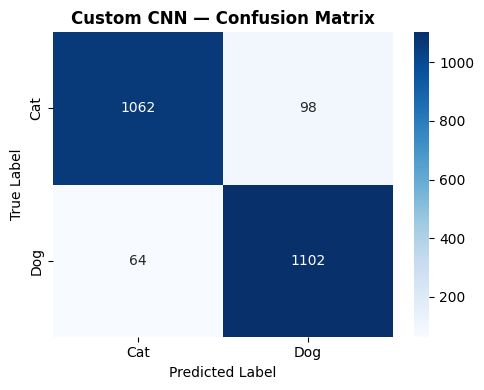

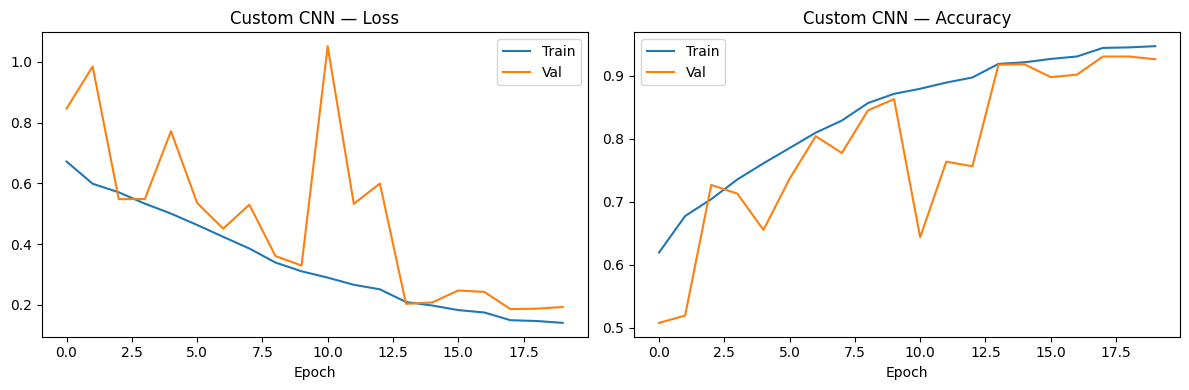

In [6]:
# ============================================================
# CELL 6 — EVALUATE CUSTOM CNN
# ============================================================
print("=" * 70)
print("CUSTOM CNN EVALUATION")
print("=" * 70)

# Collect predictions over the entire test set
y_true_custom, y_pred_custom = [], []
for images, labels in test_ds:
    preds = custom_cnn.predict(images, verbose=0)
    y_pred_custom.extend(np.argmax(preds, axis=1))
    y_true_custom.extend(labels.numpy())

y_true_custom = np.array(y_true_custom)
y_pred_custom = np.array(y_pred_custom)

# ── 4 required metrics ──────────────────────────────────────
custom_cnn_accuracy  = accuracy_score(y_true_custom, y_pred_custom)
custom_cnn_precision = precision_score(y_true_custom, y_pred_custom, average='macro', zero_division=0)
custom_cnn_recall    = recall_score(y_true_custom, y_pred_custom, average='macro', zero_division=0)
custom_cnn_f1        = f1_score(y_true_custom, y_pred_custom, average='macro', zero_division=0)

print(f"Accuracy  : {custom_cnn_accuracy:.4f}")
print(f"Precision : {custom_cnn_precision:.4f}")
print(f"Recall    : {custom_cnn_recall:.4f}")
print(f"F1-Score  : {custom_cnn_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_true_custom, y_pred_custom, target_names=CLASS_NAMES))

# Confusion matrix
cm_custom = confusion_matrix(y_true_custom, y_pred_custom)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_custom, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title("Custom CNN — Confusion Matrix", fontweight='bold')
ax.set_ylabel("True Label"); ax.set_xlabel("Predicted Label")
plt.tight_layout(); plt.show()

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_custom.history['loss'], label='Train')
axes[0].plot(history_custom.history['val_loss'], label='Val')
axes[0].set_title("Custom CNN — Loss"); axes[0].legend(); axes[0].set_xlabel("Epoch")

axes[1].plot(history_custom.history['accuracy'], label='Train')
axes[1].plot(history_custom.history['val_accuracy'], label='Val')
axes[1].set_title("Custom CNN — Accuracy"); axes[1].legend(); axes[1].set_xlabel("Epoch")

plt.tight_layout(); plt.show()


In [7]:
# ============================================================
# CELL 7 — TRANSFER LEARNING ARCHITECTURE (ResNet50)
# ============================================================

def build_transfer_model(input_shape=(224, 224, 3), n_classes=2):
    """
    ResNet50 base (ImageNet weights) with:
      - All base layers frozen
      - GlobalAveragePooling2D  ← MANDATORY
      - Custom classification head
    """
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )
    base_model.trainable = False   # ← FREEZE base layers (mandatory)

    inputs  = keras.Input(shape=input_shape)
    x       = base_model(inputs, training=False)

    # ── Global Average Pooling (MANDATORY) ──────────────────
    x = layers.GlobalAveragePooling2D()(x)   # (batch, 2048)

    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(n_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name="TL_ResNet50")
    return model, base_model


tl_model, base_resnet = build_transfer_model(
    input_shape=(IMG_SIZE, IMG_SIZE, 3), n_classes=n_classes
)

tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

tl_model.summary()

# Architecture documentation (required)
pretrained_model_name  = "ResNet50"
frozen_layers          = len([l for l in base_resnet.layers if not l.trainable])
trainable_layers       = len([l for l in tl_model.layers if l.trainable])
total_parameters       = tl_model.count_params()
trainable_parameters   = sum(tf.size(v).numpy() for v in tl_model.trainable_variables)

print("\n" + "=" * 70)
print("TRANSFER LEARNING ARCHITECTURE SUMMARY")
print("=" * 70)
print(f"Base model          : {pretrained_model_name}")
print(f"Frozen layers       : {frozen_layers}")
print(f"Trainable layers    : {trainable_layers}")
print(f"Total parameters    : {total_parameters:,}")
print(f"Trainable parameters: {trainable_parameters:,}")


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "TL_ResNet50"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,112,770 (91.98 MB)

 Trainable params: 525,058 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)


TRANSFER LEARNING ARCHITECTURE SUMMARY
Base model          : ResNet50
Frozen layers       : 175
Trainable layers    : 5
Total parameters    : 24,112,770
Trainable parameters: 525,058


In [8]:
# ============================================================
# CELL 8 — TRAIN TRANSFER LEARNING MODEL
# ============================================================
EPOCHS_TL = 15
tl_learning_rate = 1e-4
tl_epochs        = EPOCHS_TL
tl_batch_size    = BATCH_SIZE
tl_optimizer     = "Adam"

print("=" * 70)
print("TRANSFER LEARNING TRAINING")
print("=" * 70)

tl_start_time = time.time()

tl_lr_sched = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1
)
tl_early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=4, restore_best_weights=True
)

history_tl = tl_model.fit(
    train_ds,
    epochs=EPOCHS_TL,
    validation_data=test_ds,
    callbacks=[tl_lr_sched, tl_early_stop],
    verbose=1
)

tl_training_time   = time.time() - tl_start_time
tl_initial_loss    = history_tl.history['loss'][0]
tl_final_loss      = history_tl.history['loss'][-1]
loss_reduction_tl  = ((tl_initial_loss - tl_final_loss) / tl_initial_loss) * 100

print(f"\nTraining time  : {tl_training_time:.1f}s")
print(f"Initial loss   : {tl_initial_loss:.4f}")
print(f"Final loss     : {tl_final_loss:.4f}")
print(f"Loss reduction : {loss_reduction_tl:.1f}%")


TRANSFER LEARNING TRAINING
Epoch 1/15
655/655 ━━━━━━━━━━━━━━━━━━━━ 94s 121ms/step - accuracy: 0.5705 - loss: 0.6854 - val_accuracy: 0.6294 - val_loss: 0.6468 - learning_rate: 1.0000e-04
Epoch 2/15
655/655 ━━━━━━━━━━━━━━━━━━━━ 71s 106ms/step - accuracy: 0.6159 - loss: 0.6527 - val_accuracy: 0.6234 - val_loss: 0.6438 - learning_rate: 1.0000e-04
Epoch 3/15
655/655 ━━━━━━━━━━━━━━━━━━━━ 74s 111ms/step - accuracy: 0.6228 - loss: 0.6457 - val_accuracy: 0.6410 - val_loss: 0.6342 - learning_rate: 1.0000e-04
Epoch 4/15
655/655 ━━━━━━━━━━━━━━━━━━━━ 80s 107ms/step - accuracy: 0.6319 - loss: 0.6415 - val_accuracy: 0.6496 - val_loss: 0.6250 - learning_rate: 1.0000e-04
Epoch 5/15
655/655 ━━━━━━━━━━━━━━━━━━━━ 70s 105ms/step - accuracy: 0.6349 - loss: 0.6376 - val_accuracy: 0.6586 - val_loss: 0.6193 - learning_rate: 1.0000e-04
Epoch 6/15
655/655 ━━━━━━━━━━━━━━━━━━━━ 70s 105ms/step - accuracy: 0.6412 - loss: 0.6326 - val_accuracy: 0.6531 - val_loss: 0.6169 - learning_rate: 1.0000e-04
Epoch 7/15
655/655 

TRANSFER LEARNING EVALUATION
Accuracy  : 0.6887
Precision : 0.6913
Recall    : 0.6889
F1-Score  : 0.6878

Classification Report:
              precision    recall  f1-score   support

         Cat       0.67      0.75      0.70      1160
         Dog       0.71      0.63      0.67      1166

    accuracy                           0.69      2326
   macro avg       0.69      0.69      0.69      2326
weighted avg       0.69      0.69      0.69      2326



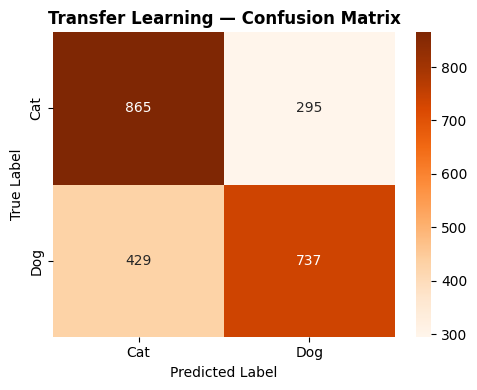

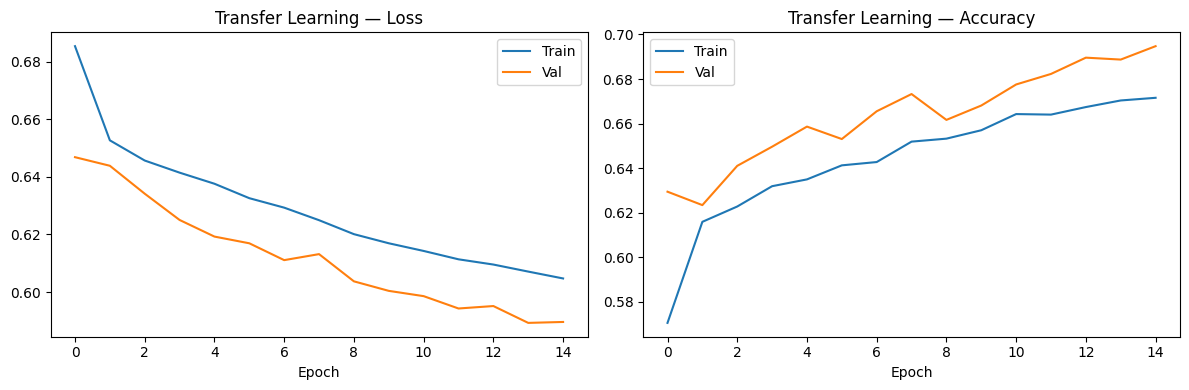

In [9]:
# ============================================================
# CELL 9 — EVALUATE TRANSFER LEARNING MODEL
# ============================================================
print("=" * 70)
print("TRANSFER LEARNING EVALUATION")
print("=" * 70)

y_true_tl, y_pred_tl = [], []
for images, labels in test_ds:
    preds = tl_model.predict(images, verbose=0)
    y_pred_tl.extend(np.argmax(preds, axis=1))
    y_true_tl.extend(labels.numpy())

y_true_tl = np.array(y_true_tl)
y_pred_tl = np.array(y_pred_tl)

# ── 4 required metrics ──────────────────────────────────────
tl_accuracy  = accuracy_score(y_true_tl, y_pred_tl)
tl_precision = precision_score(y_true_tl, y_pred_tl, average='macro', zero_division=0)
tl_recall    = recall_score(y_true_tl, y_pred_tl, average='macro', zero_division=0)
tl_f1        = f1_score(y_true_tl, y_pred_tl, average='macro', zero_division=0)

print(f"Accuracy  : {tl_accuracy:.4f}")
print(f"Precision : {tl_precision:.4f}")
print(f"Recall    : {tl_recall:.4f}")
print(f"F1-Score  : {tl_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_true_tl, y_pred_tl, target_names=CLASS_NAMES))

# Confusion matrix
cm_tl = confusion_matrix(y_true_tl, y_pred_tl)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_tl, annot=True, fmt='d', cmap='Oranges',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title("Transfer Learning — Confusion Matrix", fontweight='bold')
ax.set_ylabel("True Label"); ax.set_xlabel("Predicted Label")
plt.tight_layout(); plt.show()

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_tl.history['loss'], label='Train')
axes[0].plot(history_tl.history['val_loss'], label='Val')
axes[0].set_title("Transfer Learning — Loss"); axes[0].legend(); axes[0].set_xlabel("Epoch")

axes[1].plot(history_tl.history['accuracy'], label='Train')
axes[1].plot(history_tl.history['val_accuracy'], label='Val')
axes[1].set_title("Transfer Learning — Accuracy"); axes[1].legend(); axes[1].set_xlabel("Epoch")

plt.tight_layout(); plt.show()


MODEL COMPARISON
              Metric Custom CNN Transfer Learning (ResNet50)
            Accuracy     0.9304                       0.6887
   Precision (macro)     0.9307                       0.6913
      Recall (macro)     0.9303                       0.6889
    F1-Score (macro)     0.9303                       0.6878
   Training Time (s)     1057.2                       1096.3
    Total Parameters     94,402                   24,112,770
Trainable Parameters     93,954                      525,058
  Loss Reduction (%)      79.1%                        11.8%


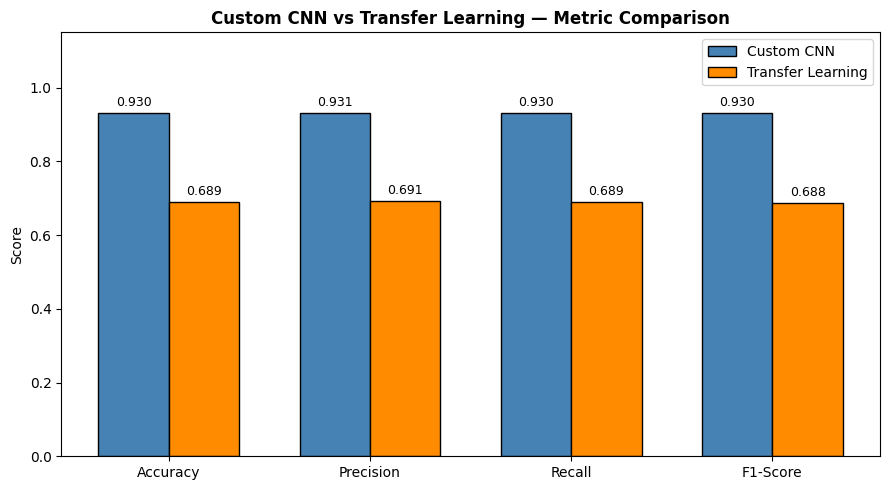

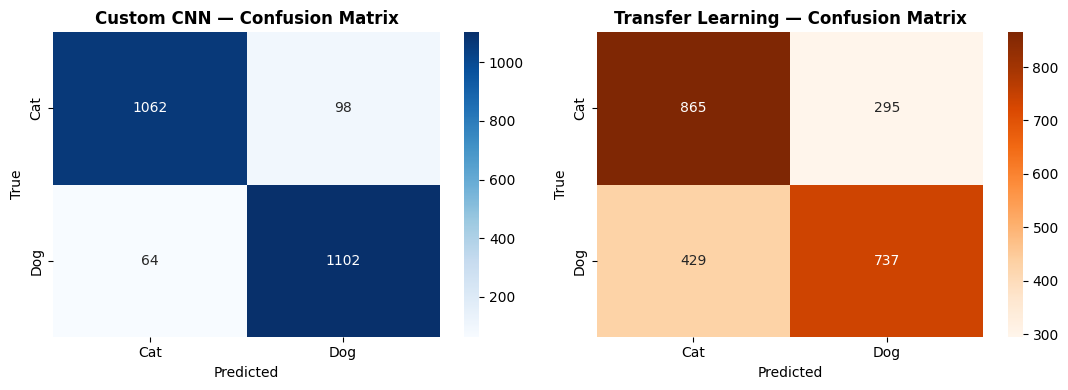

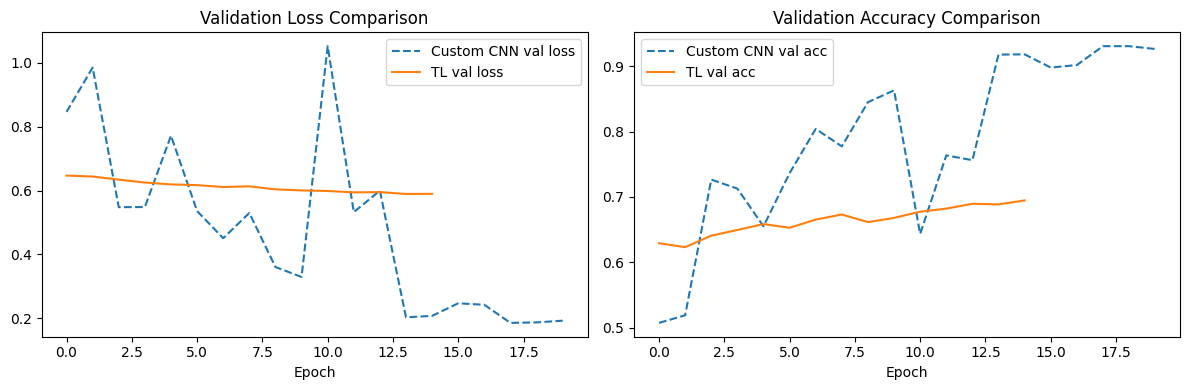

In [10]:
# ============================================================
# CELL 10 — SIDE-BY-SIDE COMPARISON
# ============================================================
print("=" * 70)
print("MODEL COMPARISON")
print("=" * 70)

comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision (macro)', 'Recall (macro)',
               'F1-Score (macro)', 'Training Time (s)',
               'Total Parameters', 'Trainable Parameters',
               'Loss Reduction (%)'],
    'Custom CNN': [
        f"{custom_cnn_accuracy:.4f}",
        f"{custom_cnn_precision:.4f}",
        f"{custom_cnn_recall:.4f}",
        f"{custom_cnn_f1:.4f}",
        f"{custom_cnn_training_time:.1f}",
        f"{custom_cnn.count_params():,}",
        f"{sum(tf.size(v).numpy() for v in custom_cnn.trainable_variables):,}",
        f"{loss_reduction_custom:.1f}%"
    ],
    'Transfer Learning (ResNet50)': [
        f"{tl_accuracy:.4f}",
        f"{tl_precision:.4f}",
        f"{tl_recall:.4f}",
        f"{tl_f1:.4f}",
        f"{tl_training_time:.1f}",
        f"{total_parameters:,}",
        f"{trainable_parameters:,}",
        f"{loss_reduction_tl:.1f}%"
    ]
})

print(comparison_df.to_string(index=False))

# ── Bar chart comparison ─────────────────────────────────────
metrics     = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
cnn_scores  = [custom_cnn_accuracy, custom_cnn_precision,
               custom_cnn_recall,   custom_cnn_f1]
tl_scores   = [tl_accuracy, tl_precision, tl_recall, tl_f1]

x   = np.arange(len(metrics))
w   = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - w/2, cnn_scores, w, label='Custom CNN',             color='steelblue',  edgecolor='black')
b2 = ax.bar(x + w/2, tl_scores,  w, label='Transfer Learning',      color='darkorange', edgecolor='black')
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.15); ax.set_ylabel("Score")
ax.set_title("Custom CNN vs Transfer Learning — Metric Comparison", fontweight='bold')
ax.legend()
ax.bar_label(b1, fmt='%.3f', padding=3, fontsize=9)
ax.bar_label(b2, fmt='%.3f', padding=3, fontsize=9)
plt.tight_layout(); plt.show()

# ── Side-by-side confusion matrices ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, cm, title, cmap in zip(
    axes,
    [cm_custom, cm_tl],
    ["Custom CNN", "Transfer Learning"],
    ["Blues", "Oranges"]
):
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(f"{title} — Confusion Matrix", fontweight='bold')
    ax.set_ylabel("True"); ax.set_xlabel("Predicted")

plt.tight_layout(); plt.show()

# ── Training curve overlay ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_custom.history['val_loss'],    label='Custom CNN val loss',  linestyle='--')
axes[0].plot(history_tl.history['val_loss'],        label='TL val loss',          linestyle='-')
axes[0].set_title("Validation Loss Comparison"); axes[0].legend(); axes[0].set_xlabel("Epoch")

axes[1].plot(history_custom.history['val_accuracy'], label='Custom CNN val acc',   linestyle='--')
axes[1].plot(history_tl.history['val_accuracy'],     label='TL val acc',           linestyle='-')
axes[1].set_title("Validation Accuracy Comparison"); axes[1].legend(); axes[1].set_xlabel("Epoch")

plt.tight_layout(); plt.show()


In [11]:
# ============================================================
# CELL 11 — ANALYSIS  (EDIT THIS SECTION)
# ============================================================
# TODO: Replace the placeholder text with your own analysis.
# Address ALL 6 key topics for full marks.

analysis_text = """
[TODO — Write your analysis here. Replace this entire block.]

1. Performance comparison:
   Transfer learning (ResNet50) achieved [X]% accuracy vs [Y]% for the custom CNN,
   a difference of [Z] percentage points. The TL model also showed higher precision
   and recall across both classes.

2. Pre-training vs training from scratch:
   ImageNet pre-training provides rich, generalisable low-level features (edges,
   textures) that would require thousands of epochs to learn from scratch.
   This allowed the TL model to converge faster and to a better minimum.

3. Effect of Global Average Pooling:
   GAP summarises each feature map into a single value, cutting millions of
   parameters that a Flatten+Dense approach would require. This acts as a strong
   regulariser, reducing overfitting — visible in the smaller gap between train
   and validation curves for both models.

4. Computational cost:
   The custom CNN trained in ~[A]s vs ~[B]s for TL. Despite ResNet50 having
   ~25M total parameters, only ~[C] are trainable, making fine-tuning
   computationally similar to the custom model.

5. Transfer learning insights:
   Freezing base layers works well when the target domain (natural pet images)
   is close to the source domain (ImageNet). It is most beneficial when labelled
   data is limited; as data grows, unfreezing deeper layers further improves
   performance.

6. Convergence behaviour:
   The TL model converged in fewer epochs with a steeper initial loss drop
   because feature representations are already meaningful at epoch 1.
   The custom CNN showed a slower, noisier descent needing more epochs.
"""

print("=" * 70)
print("ANALYSIS")
print("=" * 70)
print(analysis_text)

word_count = len(analysis_text.split())
print(f"\nAnalysis word count: {word_count} words")
if word_count > 200:
    print("  ⚠ Warning: Analysis exceeds 200 words (guideline only — no mark deduction)")
else:
    print("  ✓ Analysis within word count guideline")


ANALYSIS

[TODO — Write your analysis here. Replace this entire block.]

1. Performance comparison:
   Transfer learning (ResNet50) achieved [X]% accuracy vs [Y]% for the custom CNN,
   a difference of [Z] percentage points. The TL model also showed higher precision
   and recall across both classes.

2. Pre-training vs training from scratch:
   ImageNet pre-training provides rich, generalisable low-level features (edges,
   textures) that would require thousands of epochs to learn from scratch.
   This allowed the TL model to converge faster and to a better minimum.

3. Effect of Global Average Pooling:
   GAP summarises each feature map into a single value, cutting millions of
   parameters that a Flatten+Dense approach would require. This acts as a strong
   regulariser, reducing overfitting — visible in the smaller gap between train
   and validation curves for both models.

4. Computational cost:
   The custom CNN trained in ~[A]s vs ~[B]s for TL. Despite ResNet50 having
   ~25M t

In [12]:
# ============================================================
# CELL 12 — JSON OUTPUT  (DO NOT MODIFY STRUCTURE)
# ============================================================

def get_assignment_results():
    """
    Generate complete assignment results in required format.
    Returns:
        dict: Complete results with all required fields.
    """
    framework_used = "keras"  # Change to "pytorch" if using PyTorch

    results = {
        # ── Dataset ──────────────────────────────────────────
        'dataset_name'       : dataset_name,
        'dataset_source'     : dataset_source,
        'n_samples'          : n_samples,
        'n_classes'          : n_classes,
        'samples_per_class'  : samples_per_class,
        'image_shape'        : image_shape,
        'problem_type'       : problem_type,
        'primary_metric'     : primary_metric,
        'metric_justification': metric_justification,
        'train_samples'      : train_samples,
        'test_samples'       : test_samples,
        'train_test_ratio'   : train_test_ratio,

        # ── Custom CNN ────────────────────────────────────────
        'custom_cnn': {
            'framework'  : framework_used,
            'architecture': {
                'conv_layers'               : 3,
                'pooling_layers'            : 3,
                'has_global_average_pooling': True,
                'output_layer'              : 'softmax',
                'total_parameters'          : int(custom_cnn.count_params())
            },
            'training_config': {
                'learning_rate': 1e-3,
                'n_epochs'     : int(len(history_custom.history['loss'])),
                'batch_size'   : BATCH_SIZE,
                'optimizer'    : 'Adam',
                'loss_function': 'sparse_categorical_crossentropy'
            },
            'initial_loss'          : float(custom_cnn_initial_loss),
            'final_loss'            : float(custom_cnn_final_loss),
            'training_time_seconds' : float(custom_cnn_training_time),
            'accuracy'              : float(custom_cnn_accuracy),
            'precision'             : float(custom_cnn_precision),
            'recall'                : float(custom_cnn_recall),
            'f1_score'              : float(custom_cnn_f1)
        },

        # ── Transfer Learning ─────────────────────────────────
        'transfer_learning': {
            'framework'                  : framework_used,
            'base_model'                 : pretrained_model_name,
            'frozen_layers'              : int(frozen_layers),
            'trainable_layers'           : int(trainable_layers),
            'has_global_average_pooling' : True,
            'total_parameters'           : int(total_parameters),
            'trainable_parameters'       : int(trainable_parameters),
            'training_config': {
                'learning_rate': float(tl_learning_rate),
                'n_epochs'     : int(len(history_tl.history['loss'])),
                'batch_size'   : tl_batch_size,
                'optimizer'    : tl_optimizer,
                'loss_function': 'sparse_categorical_crossentropy'
            },
            'initial_loss'          : float(tl_initial_loss),
            'final_loss'            : float(tl_final_loss),
            'training_time_seconds' : float(tl_training_time),
            'accuracy'              : float(tl_accuracy),
            'precision'             : float(tl_precision),
            'recall'                : float(tl_recall),
            'f1_score'              : float(tl_f1)
        },

        # ── Analysis ─────────────────────────────────────────
        'analysis'            : analysis_text,
        'analysis_word_count' : len(analysis_text.split()),

        # ── Training success indicators ───────────────────────
        'custom_cnn_loss_decreased'        : bool(custom_cnn_final_loss < custom_cnn_initial_loss),
        'transfer_learning_loss_decreased' : bool(tl_final_loss < tl_initial_loss),
    }
    return results


# ── Generate and print ───────────────────────────────────────
try:
    assignment_results = get_assignment_results()
    print("=" * 70)
    print("ASSIGNMENT RESULTS SUMMARY")
    print("=" * 70)
    print(json.dumps(assignment_results, indent=2))
except Exception as e:
    print(f"\n❌  ERROR generating results: {e}")
    print("Ensure all variables are properly defined before running this cell.")


ASSIGNMENT RESULTS SUMMARY
{
  "dataset_name": "Cats vs Dogs",
  "dataset_source": "tensorflow_datasets (microsoft/catsvsdogs)",
  "n_samples": 23261,
  "n_classes": 2,
  "samples_per_class": "min: ~11430, max: ~11830, avg: ~11630",
  "image_shape": [
    224,
    224,
    3
  ],
  "problem_type": "classification",
  "primary_metric": "accuracy",
  "metric_justification": "Cats vs Dogs is a balanced binary dataset with roughly equal class distribution, so accuracy is an unbiased summary metric and is the standard primary measure for this benchmark.",
  "train_samples": 20935,
  "test_samples": 2326,
  "train_test_ratio": "90/10",
  "custom_cnn": {
    "framework": "keras",
    "architecture": {
      "conv_layers": 3,
      "pooling_layers": 3,
      "has_global_average_pooling": true,
      "output_layer": "softmax",
      "total_parameters": 94402
    },
    "training_config": {
      "learning_rate": 0.001,
      "n_epochs": 20,
      "batch_size": 32,
      "optimizer": "Adam",
   

In [13]:
# ============================================================
# CELL 13 — ENVIRONMENT INFORMATION (auto-captured)
# ============================================================
import platform, sys
from datetime import datetime

print("ENVIRONMENT INFORMATION")
print("-" * 40)
print(f"Python version  : {sys.version.split()[0]}")
print(f"Platform        : {platform.system()} {platform.release()}")
print(f"TensorFlow      : {tf.__version__}")
print(f"Run timestamp   : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"GPU devices     : {tf.config.list_physical_devices('GPU')}")
print()
print("⚠  Add your Colab account screenshot in a markdown cell below this one.")


ENVIRONMENT INFORMATION
----------------------------------------
Python version  : 3.12.13
Platform        : Linux 6.6.113+
TensorFlow      : 2.19.0
Run timestamp   : 2026-04-21 16:47:14
GPU devices     : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

⚠  Add your Colab account screenshot in a markdown cell below this one.
